# Adaptive RAG

**Flow:** `route (vectorstore vs. web) -> retrieve or search -> grade documents ->
generate -> grade the generation itself (hallucination + answer-quality) -> loop if needed`

This is the most involved of the three patterns. It combines ideas from both other
notebooks and adds one more: **self-correction on the output**, not just the input.
Before returning an answer, the pipeline checks whether the generation is actually
grounded in the retrieved documents (not hallucinated) and whether it actually answers
the question — and if either check fails, it loops back and tries again.

**Flow, in more detail:**
1. `route_question` — an LLM call decides up front: does this question belong in our
   vectorstore, or does it need a live web search?
2. `retrieve` (vectorstore path) or `web_search` (web path)
3. `grade_documents` — score relevance; if nothing relevant survives, `transform_query`
   and retry down the *same* path the question was originally routed to
4. `generate` — write an answer
5. `grade_generation_v_documents_and_question` — check the answer isn't hallucinated and
   actually addresses the question; loop back to `generate` or `transform_query` if not

Run the cells top to bottom. You'll need `GROQ_API_KEY` and `TAVILY_API_KEY` — see the
README for setup with `uv`.


## 1. Imports

In [1]:
import os
from dotenv import load_dotenv
from IPython.display import Image, display
import requests
from bs4 import BeautifulSoup
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.tools import tool
from langchain_core.messages import (
    BaseMessage,
    AnyMessage,
    HumanMessage,
    AIMessage,
    SystemMessage
)
from langchain_core.output_parsers import StrOutputParser
from typing import Annotated, get_type_hints, List
from pydantic import BaseModel, Field
from langgraph.graph.message import add_messages
from typing import Literal
from langchain_tavily import TavilySearch
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate, SystemMessagePromptTemplate, HumanMessagePromptTemplate


## 2. Load API keys

In [2]:
load_dotenv()

GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

## 3. Initialize the LLM

In [3]:
groq_llm = ChatGroq(
    api_key=GROQ_API_KEY,
    model="openai/gpt-oss-120b",
    temperature=0
)

## 4. Web search fallback (Tavily)
Defined up front this time, since the router may send a question here directly instead of only using it as a correction step.

In [4]:
tavily_client = TavilySearch(
    max_results=5,
    topic="general",
    tavily_api_key=TAVILY_API_KEY,
)


def tavily_search(query: str) -> str:
    """Search the web using Tavily and return titles, URLs, and content snippets."""
    try:
        response = tavily_client.invoke({"query": query})
    except Exception as e:
        return f"Tavily exception: {e}"

    results = response.get("results", [])

    docs = []
    for r in results:
        doc = (
            f"Title: {r.get('title', '')}\n"
            f"URL: {r.get('url', '')}\n"
            f"Content: {r.get('content', '')[:500]}"
        )
        docs.append(doc)

    if docs:
        return "\n\n".join(docs)
    else:
        return "No results found."

## 5. Scrape the source documents
Same Lilian Weng blog posts used in the Corrective RAG notebook, so you can compare how the two patterns handle the same underlying knowledge base.

In [5]:
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]

docs = []

headers = {"User-Agent": "Mozilla/5.0"}

for url in urls:
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, "html.parser")
    
    title = soup.title.string.strip() if soup.title else "No title"
    text = soup.get_text(separator="\n", strip=True)
    
    docs.append({"source": url, "title": title, "text": text})

## 6. Wrap pages as `Document` objects

In [6]:
documents = []

for doc in docs:
    document = Document(
        page_content=doc["text"],
        metadata={"source": doc["source"], "title": doc["title"]}
    )
    documents.append(document)
    
documents

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log"}, page_content='LLM Powered Autonomous Agents | Lil\'Log\nLil\'Log\n|\nPosts\nArchive\nSearch\nTags\nFAQ\nLLM Powered Autonomous Agents\nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng\nTable of Contents\nAgent System Overview\nComponent One: Planning\nTask Decomposition\nSelf-Reflection\nComponent Two: Memory\nTypes of Memory\nMaximum Inner Product Search (MIPS)\nComponent Three: Tool Use\nCase Studies\nScientific Discovery Agent\nGenerative Agents Simulation\nProof-of-Concept Examples\nChallenges\nCitation\nReferences\nBuilding agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as\nAutoGPT\n,\nGPT-Engineer\nand\nBabyAGI\n, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; i

## 7. Chunk the documents

In [7]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

chunks = text_splitter.split_documents(documents)

## 8. Create the embedding model

In [8]:
embedding_model = HuggingFaceEmbeddings(
    model_name="BAAI/bge-m3",
    show_progress=True,
    encode_kwargs={"batch_size": 32}
)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

## 9. Build the vector store

In [9]:
vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embedding_model,
    collection_name="docs"
)

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

## 10. Create the retriever

In [10]:
retriever = vectorstore.as_retriever(
    search_kwargs={"k": 3}
)

## 11. Router
The question is routed to either `vectorstore` or `web_search` *before* any retrieval happens — this is what makes the pipeline adaptive rather than fixed. The router is told what topics the vectorstore covers, so it can send anything outside that scope straight to the web.

In [11]:
# Router

class RouteQuery(BaseModel):
    """Route a user query to the most relevant datasource."""

    datasource: Literal["vectorstore", "web_search"] = Field(
        ...,
        description="Given a user question choose to route it to web search or a vectorstore.",
    )
    
structured_llm_router = groq_llm.with_structured_output(RouteQuery)

route_prompt = ChatPromptTemplate.from_messages(
    [
        SystemMessagePromptTemplate.from_template("""Decide where a user's question should be answered from: the vectorstore or a live web search.
The vectorstore only covers agents, prompt engineering, and adversarial attacks on LLMs.
Route anything on those topics to the vectorstore; send everything else to the web."""),

        HumanMessagePromptTemplate.from_template("{question}"),
    ]
)

question_router = route_prompt | structured_llm_router

print(
    question_router.invoke(
        {"question": "Who won the Cricket world cup 2023 "}
    )
)


datasource='web_search'


## 12. Document relevance grader
Same pattern as Corrective RAG: score each retrieved chunk `yes`/`no`.

In [12]:
# Retrieval Grader

class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""

    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )
    
structured_llm_grader = groq_llm.with_structured_output(GradeDocuments)

grade_prompt = ChatPromptTemplate.from_messages(
    [
        SystemMessagePromptTemplate.from_template("""Decide whether a retrieved passage is actually useful for answering a question. \n 
Count it as relevant if it overlaps with the question either in specific keywords or in overall meaning. \n
Keep the bar low here — the goal is just to catch clearly unrelated results, not to demand a perfect match. \n
Reply with only 'yes' or 'no'."""),

        HumanMessagePromptTemplate.from_template("Retrieved passage: \n\n {document} \n\n Question: {question}"),
    ]
)

retrieval_grader = grade_prompt | structured_llm_grader

question = "agent memory"
## context
docs = retriever.invoke(question)
doc_txt = docs[1].page_content
print(retrieval_grader.invoke({"question": question, "document": doc_txt}))

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

binary_score='yes'


## 13. Generation chain
Plain RAG answer chain, tested directly before being wired into the graph.

In [13]:
# Generate

prompt = ChatPromptTemplate.from_template(
    """ 
    Answer the question using only the context provided below.
    If the context doesn't give you enough to answer, say you don't know instead of guessing.
    Keep the answer to three sentences or fewer.

    Question: {question}
    Context: {context}
    Answer:
    """
    )

rag_chain = prompt | groq_llm | StrOutputParser()

generation = rag_chain.invoke({"context": docs, "question": question})
print(generation)

Agent memory consists of two layers: short‑term memory uses the model’s in‑context learning to retain recent prompts and responses, while long‑term memory stores an ever‑growing external database (e.g., a vector store) of past observations and events. The long‑term store can be queried by relevance, recency, and importance to inform the agent’s future actions and reflections. This combination lets autonomous agents recall both immediate context and extensive historical experience.


## 14. Hallucination grader
Checks whether the generated answer is actually supported by the retrieved documents, rather than made up.

In [14]:
# Hallucination Grader

class GradeHallucinations(BaseModel):
    """Binary score for hallucination present in generation answer."""

    binary_score: str = Field(
        description="Answer is grounded in the facts, 'yes' or 'no'"
    )
    
structured_llm_grader = groq_llm.with_structured_output(GradeHallucinations)

hallucination_prompt = ChatPromptTemplate.from_messages(
    [
        SystemMessagePromptTemplate.from_template("""Check whether a generated answer is actually backed up by the supplied facts, rather than invented. \n 
     Reply with only 'yes' or 'no' — 'yes' if every claim in the answer traces back to the facts given."""),

        HumanMessagePromptTemplate.from_template("Set of facts: \n\n {documents} \n\n LLM generation: {generation}"),
    ]
)

hallucination_grader = hallucination_prompt | structured_llm_grader
hallucination_grader.invoke({"documents": docs, "generation": generation})


GradeHallucinations(binary_score='yes')

## 15. Answer-quality grader
A second, separate check: even if the answer is grounded in the documents, does it actually resolve the user's question?

In [15]:
# Answer Grader

class GradeAnswer(BaseModel):
    """Binary score to assess answer addresses question."""

    binary_score: str = Field(
        description="Answer addresses the question, 'yes' or 'no'"
    )
    
structured_llm_grader = groq_llm.with_structured_output(GradeAnswer)

answer_prompt = ChatPromptTemplate.from_messages(
    [
        SystemMessagePromptTemplate.from_template("""Check whether a generated answer actually resolves the user's question, separate from whether it's factually grounded. \n 
     Reply with only 'yes' or 'no' — 'yes' if it answers what was asked."""),

        HumanMessagePromptTemplate.from_template("User question: \n\n {question} \n\n LLM generation: {generation}"),
    ]
)

answer_grader = answer_prompt | structured_llm_grader
answer_grader.invoke({"question": question, "generation": generation})

GradeAnswer(binary_score='yes')

## 16. Question rewriter
Used when documents come back irrelevant, to retry with a better-phrased question on the same path (vectorstore or web) the question was originally routed to.

In [16]:
# Question Re-writer

system = """Rewrite the question below so it retrieves better matches from the vectorstore. \n 
     Focus on the intent behind the question rather than its exact original wording."""
re_write_prompt = ChatPromptTemplate.from_messages(
    [
        SystemMessagePromptTemplate.from_template("""Rewrite the question below so it retrieves better matches from the vectorstore. \n 
     Focus on the intent behind the question rather than its exact original wording."""),

        HumanMessagePromptTemplate.from_template("Here is the initial question: \n\n {question} \n Formulate an improved question."),
    ]
)

question_rewriter = re_write_prompt | groq_llm | StrOutputParser()
question_rewriter.invoke({"question": question})

'**Improved question:**  \n*What are the most effective methods for implementing and managing memory in autonomous AI agents, and how can these memory systems be queried or retrieved during operation?*'

## 17. Define the graph state
Adds a `datasource` field (not present in the Corrective RAG state) that remembers which path — vectorstore or web — the question was routed to, so later retries stay on that same path instead of silently switching.

In [17]:
class GraphState(BaseModel):
    question: str
    generation: str = ""
    documents: List[Document] = Field(default_factory=list)
    datasource: str = ""  # tracks which path we're on: "web_search" or "vectorstore"


## 18. Define the graph nodes
- `retrieve` / `web_search` — the two possible entry paths
- `grade_documents` — score relevance
- `generate` — write an answer
- `transform_query` — rewrite the question when documents aren't relevant
- `route_question` / `decide_route` — pick vectorstore vs. web up front
- `decide_to_generate` — after grading, generate or go correct the query
- `route_after_transform` — after a rewrite, retry the *original* path rather than defaulting to one
- `grade_generation_v_documents_and_question` — the output self-check: hallucination + answer quality

In [18]:
def retrieve(state):
    """
    Retrieve documents

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, documents, that contains retrieved documents
    """
    print("---RETRIEVE---")
    question = state.question

    documents = retriever.invoke(question)
    return {"documents": documents, "question": question}


def generate(state):
    """
    Generate answer

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """
    print("---GENERATE---")
    question = state.question
    documents = state.documents

    # RAG generation
    generation = rag_chain.invoke({"context": documents, "question": question})
    return {"documents": documents, "question": question, "generation": generation}


def grade_documents(state):
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    """

    print("---CHECK DOCUMENT RELEVANCE TO QUESTION---")
    question = state.question
    documents = state.documents

    # Score each doc
    filtered_docs = []
    for d in documents:
        score = retrieval_grader.invoke({"question": question, "document": d.page_content})
        grade = score.binary_score
        if grade == "yes":
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            print("---GRADE: DOCUMENT NOT RELEVANT---")
            continue
    return {"documents": filtered_docs, "question": question}


def transform_query(state):
    """
    Transform the query to produce a better question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates question key with a re-phrased question
    """

    print("---TRANSFORM QUERY---")
    question = state.question
    documents = state.documents

    # Re-write question
    better_question = question_rewriter.invoke({"question": question})
    return {"documents": documents, "question": better_question}


def web_search(state):
    """
    Web search based on the re-phrased question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with fresh web results
    """

    print("---WEB SEARCH---")
    question = state.question

    # Web search
    web_results_text = tavily_search(question)
    web_results = Document(page_content=web_results_text)

    # NOTE: we replace (not append to) documents here. This node can now be
    # re-entered after a query rewrite (see transform_query routing below),
    # and appending would let stale results from a previous, worse query
    # pile up alongside the new ones and pollute the hallucination/answer grading.
    return {"documents": [web_results], "question": question}


def route_question(state):
    """
    Entry node: route the question to web search or the vectorstore, and
    remember that choice in state.datasource so later steps (like a query
    rewrite) know which path they're on.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates the datasource key
    """

    print("---ROUTE QUESTION---")
    question = state.question
    source = question_router.invoke({"question": question})
    if source.datasource == "web_search":
        print("---ROUTE QUESTION TO WEB SEARCH---")
    else:
        print("---ROUTE QUESTION TO RAG---")
    return {"question": question, "datasource": source.datasource}


def decide_route(state):
    """
    Reads the datasource decision made in route_question and sends the
    question to the matching node.

    Args:
        state (dict): The current graph state

    Returns:
        str: Next node to call
    """
    return state.datasource  # "web_search" or "vectorstore"


def decide_to_generate(state):
    """
    Determines whether to generate an answer, or re-generate a question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Binary decision for next node to call
    """

    print("---ASSESS GRADED DOCUMENTS---")

    filtered_documents = state.documents

    if not filtered_documents:
        print(
            "---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---"
        )
        return "transform_query"
    else:
        print("---DECISION: GENERATE---")
        return "generate"


def route_after_transform(state):
    """
    After the query has been rewritten, send it back to whichever
    datasource we were originally routed to, instead of always going to
    the vectorstore. This is what keeps a web_search query on the
    web_search path when its generation isn't useful, rather than
    silently switching it into the RAG path.

    Args:
        state (dict): The current graph state

    Returns:
        str: Next node to call
    """
    if state.datasource == "web_search":
        print("---RE-TRY: BACK TO WEB SEARCH WITH REWRITTEN QUERY---")
        return "web_search"
    else:
        print("---RE-TRY: BACK TO VECTORSTORE WITH REWRITTEN QUERY---")
        return "retrieve"


def grade_generation_v_documents_and_question(state):
    """
    Determines whether the generation is grounded in the document and answers question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Decision for next node to call
    """

    print("---CHECK HALLUCINATIONS---")
    question = state.question
    documents = state.documents
    generation = state.generation

    score = hallucination_grader.invoke({"documents": documents, "generation": generation})
    grade = score.binary_score

    # Check hallucination
    if grade == "yes":
        print("---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---")
        # Check question-answering
        print("---GRADE GENERATION vs QUESTION---")
        score = answer_grader.invoke({"question": question, "generation": generation})
        grade = score.binary_score
        if grade == "yes":
            print("---DECISION: GENERATION ADDRESSES QUESTION---")
            return "useful"
        else:
            print("---DECISION: GENERATION DOES NOT ADDRESS QUESTION---")
            return "not useful"
    else:
        print("---DECISION: GENERATION IS NOT GROUNDED IN DOCUMENTS, RE-TRY---")
        return "not supported"


## 19. Assemble the graph
The entry point is now `route_question`, not a fixed `retrieve` — and the exit point loops back into `generate` or `transform_query` depending on how the final self-check grades the answer.

In [ ]:
workflow = StateGraph(GraphState)

# Define the nodes
workflow.add_node("route_question", route_question)  # entry: decide + remember datasource
workflow.add_node("web_search", web_search)  # web search
workflow.add_node("retrieve", retrieve)  # retrieve
workflow.add_node("grade_documents", grade_documents)  # grade documents
workflow.add_node("generate", generate)  # generate
workflow.add_node("transform_query", transform_query)  # transform_query

# Build graph
workflow.add_edge(START, "route_question")
workflow.add_conditional_edges(
    "route_question",
    decide_route,
    {
        "web_search": "web_search",
        "vectorstore": "retrieve",
    },
)
workflow.add_edge("web_search", "generate")
workflow.add_edge("retrieve", "grade_documents")
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "transform_query": "transform_query",
        "generate": "generate",
    },
)

workflow.add_conditional_edges(
    "transform_query",
    route_after_transform,
    {
        "web_search": "web_search",
        "retrieve": "retrieve",
    },
)
workflow.add_conditional_edges(
    "generate",
    grade_generation_v_documents_and_question,
    {
        "not supported": "generate",
        "useful": END,
        "not useful": "transform_query",
    },
)

app = workflow.compile()


## 20. Compile and visualize

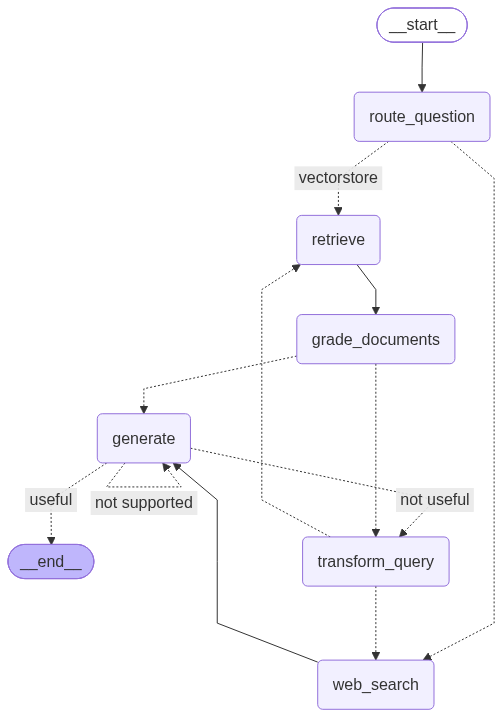

In [ ]:
# Display the graph

display(Image(app.get_graph(xray=True).draw_mermaid_png()))

## 21. Try it
A question that should route to the vectorstore.

In [21]:
app.invoke({"question":"What is machine learning"})

---ROUTE QUESTION---
---ROUTE QUESTION TO WEB SEARCH---
---WEB SEARCH---
---GENERATE---
---CHECK HALLUCINATIONS---
---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---
---GRADE GENERATION vs QUESTION---
---DECISION: GENERATION ADDRESSES QUESTION---


{'question': 'What is machine learning',
 'generation': 'Machine learning (ML) is a subfield of artificial intelligence that trains software models on data so they can make predictions, classify information, or generate content without being explicitly programmed. It uses statistical algorithms—such as supervised, unsupervised, reinforcement, or generative approaches—to learn patterns and generalize to new, unseen data. In essence, ML enables computers to improve their performance on tasks by learning from experience.',
 'documents': [Document(metadata={}, page_content='Title: What is Machine Learning?\nURL: https://developers.google.com/machine-learning/intro-to-ml/what-is-ml\nContent: Machine learning (ML) is a way to train software, called a model, to make predictions or generate content using data.\n ML systems can be categorized as supervised, unsupervised, reinforcement, or generative AI, each learning differently.\n Supervised learning uses labeled data to make predictions, ofte

## 22. Try another
A differently-scoped question, to see the router (and the rest of the self-correcting loop) in action again.

In [ ]:
app.invoke({"question":"What is agent memory?"})

---ROUTE QUESTION---
---ROUTE QUESTION TO RAG---
---RETRIEVE---


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

---CHECK DOCUMENT RELEVANCE TO QUESTION---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: GENERATE---
---GENERATE---
---CHECK HALLUCINATIONS---
---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---
---GRADE GENERATION vs QUESTION---
---DECISION: GENERATION ADDRESSES QUESTION---


{'question': 'What is agent memory',
 'generation': 'Agent memory refers to the mechanisms that let an LLM‑powered agent retain information about its past interactions. Short‑term memory is the in‑context learning used during a single prompt, while long‑term memory is an external store (e.g., a vector database) that records and retrieves experiences over extended periods. This enables the agent to recall relevant facts, observations, or actions when planning or responding.',
 'documents': [Document(id='5a086ed5-4e23-43a9-b04b-0a6179272bff', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log"}, page_content='Agent System Overview\n#\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\nPlanning\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection a